# 04 - Model Training

Trains the two models used by RiskShield AI on a temporal train/validation split: the supervised **XGBoost** fraud classifier and the unsupervised **Isolation Forest** anomaly detector. This mirrors what `run_pipeline.py` does end-to-end; this notebook is for interactively inspecting the models (feature importance, calibration) in isolation.

In [1]:
import sys
sys.path.insert(0, '.')
import pandas as pd
from pathlib import Path
from backend.features.engineering import load_raw, build_features
from backend.models.fraud_models import FraudClassifier, AnomalyDetector

txns, customers, devices, ips, merchants = load_raw(Path('data/processed'))
df, feature_cols = build_features(txns, customers, devices, ips, merchants)
for c in feature_cols:
    df[c] = df[c].fillna(0)

train_df = df[df['timestamp'] < '2025-09-01']
val_df = df[(df['timestamp'] >= '2025-09-01') & (df['timestamp'] < '2025-10-01')]
print(f'Train: {len(train_df):,}  Val: {len(val_df):,}')

Train: 78,057  Val: 9,654


## Train XGBoost fraud classifier

In [2]:
clf = FraudClassifier(feature_cols).fit(train_df, train_df['label'], val_df, val_df['label'])
val_score = clf.predict_proba(val_df)
from sklearn.metrics import average_precision_score, roc_auc_score
print(f'Validation PR-AUC: {average_precision_score(val_df["label"], val_score):.4f}')
print(f'Validation ROC-AUC: {roc_auc_score(val_df["label"], val_score):.4f}')

Validation PR-AUC: 0.9884
Validation ROC-AUC: 0.9991


## Feature importance

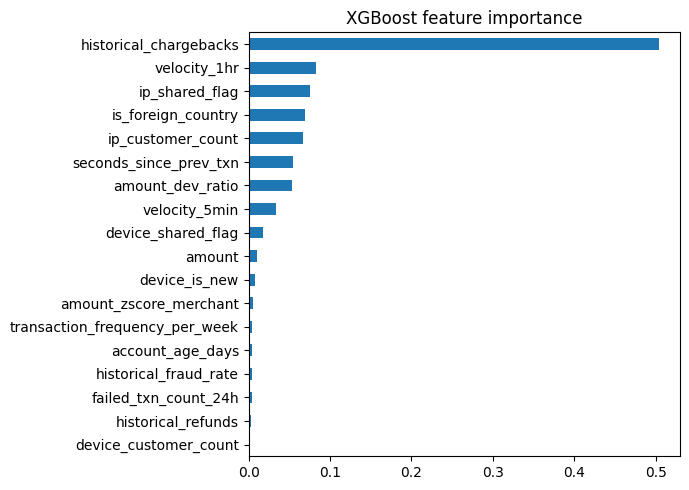

In [3]:
import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt
importances = pd.Series(clf.model.feature_importances_, index=feature_cols).sort_values()
importances.plot(kind='barh', figsize=(7,5), title='XGBoost feature importance')
plt.tight_layout(); plt.show()

## Train Isolation Forest anomaly detector

In [4]:
anom = AnomalyDetector(feature_cols, contamination=0.05).fit(train_df)
anomaly_scores = anom.score(val_df)
print(f'Mean anomaly score, legit: {anomaly_scores[val_df.label==0].mean():.3f}')
print(f'Mean anomaly score, fraud: {anomaly_scores[val_df.label==1].mean():.3f}')

Mean anomaly score, legit: 0.111
Mean anomaly score, fraud: 0.621


Both models are re-trained inside `run_pipeline.py` as part of the full end-to-end run (with the model artifacts saved to `evaluation/reports/*.joblib`); this notebook exists for quick iteration on model choices without re-running the whole pipeline.